# Prepare & Sample Gold Standard Dataset

## Overview
Todo

## Environment Setup
Installs the required packages and sets up config values.

_Note: `%%capture` disables the output of the pip install cell below. If you encounter any installation errors, please remove that line._

In [39]:
%%capture 

%pip install matplotlib pandas presidio_analyzer presidio_anonymizer nltk faker pandarallel tqdm ipywidgets ipykernel seaborn awswrangler
%pip install --upgrade nbformat

In [40]:
# Imports
import datetime

import pandas as pd
import numpy as np
import json
import re

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from tqdm.notebook import tqdm
from tqdm import tqdm
from pandarallel import pandarallel

import boto3
import awswrangler as wr

import nltk
from collections import Counter
from nltk.corpus import words

from presidio_analyzer import AnalyzerEngine, PatternRecognizer, Pattern
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig
from faker import Faker

In [41]:
# Constants
RANDOM_STATE = 42
TARGET_TOTAL = 2000
TARGET_PER_CAT = 45

# AWS
AWS_REGION = "eu-west-2"
AWS_PROFILE = "data-platform-housing-prod"
DATABASE_NAME = "housing-refined-zone"
TABLE_NAME = "additional_needs_notes_reshaped"


## Construct Taxonomy
Map the hierarchical 'Additional Needs' categories from the CSV file into snake case labels.

In [42]:
def parse_taxonomy_csv():
    """Parse and clean the taxonomy csv"""
    df = pd.read_csv("data/input/Additional Needs Taxonomy V2.csv", usecols=['Person Attribute Category', 'Description (attribute, 40 chars)', 'Value (of data type)'])
    df.dropna(inplace=True)
    columns_rename = {
        'Person Attribute Category': 'high_level_category',
        'Description (attribute, 40 chars)': 'category_description',
        'Value (of data type)': 'values_hint'
    }
    df.rename(columns=columns_rename, inplace=True)
    df['values_hint'] = df['values_hint'].str.split("\n")
    return df

def make_label(*parts):
    """Create a snake_case label from multiple parts (stripping special characters)"""
    label = '_'.join(p.strip().strip("'\"()[]{}") for p in parts).lower()
    label = re.sub(r'[\s]+', '_', label)
    label = re.sub(r'[^a-z0-9_]', '', label)
    return re.sub(r'_+', '_', label)

taxonomy = parse_taxonomy_csv()
taxonomy.head()

,high_level_category,category_description,values_hint
0,Care,Care experienced,"[Care leaver, Care experienced (under 25)]"
1,Care,Care setting,"[Fostered, Social care]"
2,Care,Has caring responsibility,"[Formal, Informal]"
3,Care,Social care involvement,"[Adult Social Care, Children's Social Care]"
4,Cautions,ASBO or injunction obtained,"[ASBO, Injunction]"


In [43]:
# Autogenerated labels - format: <high_level_category>_<category>
taxonomy['cat_label'] = taxonomy.apply(lambda row: make_label(row['high_level_category'], row['category_description']), axis=1)
taxonomy.head()

,high_level_category,category_description,values_hint,cat_label
0,Care,Care experienced,"[Care leaver, Care experienced (under 25)]",care_care_experienced
1,Care,Care setting,"[Fostered, Social care]",care_care_setting
2,Care,Has caring responsibility,"[Formal, Informal]",care_has_caring_responsibility
3,Care,Social care involvement,"[Adult Social Care, Children's Social Care]",care_social_care_involvement
4,Cautions,ASBO or injunction obtained,"[ASBO, Injunction]",cautions_asbo_or_injunction_obtained


In [79]:
taxonomy.to_csv("data/output/taxonomy_autogen.csv", index=False)

### Regex Mapping Logic

Create regexes for each category.

Initial labels are assigned using regular expressions based on conversations with Housing Officers. 

This provides a 'weak classification' foundation for the class imbalance analysis and subsequent stratified sampling.

In [45]:
def construct_category_regexes(taxonomy_df):
    # category names match taxonomy cat_label
    category_regex_dict = {
        # --- Care ---
        "care_care_experienced": r"\bcare experienced\b|\bcare leaver\b|\baged out of care\b|\blooked after\b|\blooked-after\b|\bfoster\w*\b",
        "care_care_setting": r"\bfostered\b|\bfoster care\b|\bfoster placement\b|\bin care\b|\bcare placement\b|\bsocial care placement\b",
        "care_has_caring_responsibility": r"\bformal carer\b|\bregistered carer\b|\bcarer.s allowance\b|\bunpaid carer\b|\bcaring for\b|\blooking after\b|\binformal carer\b|\bfamily carer\b",
        "care_social_care_involvement": r"\bsocial care\b|\bcare package\b|\bcare plan\b|\bcare coordinator\b|\bchildren.s social care\b|\bCSC\b|\bASC\b",
        
        # --- Cautions ---
        "cautions_asbo_or_injunction_obtained": r"\bASBO\b|\binjunction\b|\bcivil injunction\b|\bCriminal Behaviour Order\b|\bCBO\b",
        "cautions_dangerous_animals": r"\bdangerous dog\b|\bdog attack\b|\bdog bite\b|\baggressive dog\b|\bdangerous (?:pet|animal)\b|\breptile\b|\bsnake\b|\bstaff(?:fordshire)?\b",
        "cautions_visiting_requirements": r"\bno (?:lone|female|male) (?:visit|staff)\b|\bno lone (?:home|office) visit\b|\bpassword scheme\b|\btwo.person visit\b|\bdouble.crewed\b",
        "cautions_physical_abuse_or_threat_of": r"\bphysical abuse\b|\bthreat of physical abuse\b|\bviolent behaviour\b|\baggressive behaviour\b",
        "cautions_unclean_unsafe_living_environment": r"\bunclean\b|\bunsanitary\b|\bsharps\b|\bbiohazard\b|\bhoarder\b|\bfilthy\b|\bsqualor\b|\bunsafe (?:property|home|environment)\b",
        "cautions_verbal_abuse_or_threat_of": r"\bverbal abuse\b|\bverbally abusive\b|\bthreat\w*\b|\babuse (?:language|behaviour)\b|\bintimidati\w*\b",

        # --- Reasonable Adjustments ---
        "reasonable_adjustments_communication_needs": r"\bBSL\b|\bbraille\b|\bsign language\b|\bhearing loop\b|\binduction loop\b|\blarge print\b|\baudio format\b|\bscreen reader\b|\bcommunication support\b|\bspeech impairment\b|\baugmentative\b|\balternative communication\b|\bAAC\b|\beasy read\b|\btranslator\b",
        "reasonable_adjustments_mental_capacity": r"\badvocate\b|\bIMCA\b|\bdeputy\b|\bcourt of protection\b|\bLPA\b|\bpower of attorney\b|\bnext of kin\b|\bCFAT\b|\bclient financial affairs\b|\bcapacity assessment\b",
        
        # --- Communications ---
        "communication_digital_exclusion": r"\bno internet\b|\bno wifi\b|\bdigitally excluded\b|\bno (?:phone|device|computer|laptop|tablet)\b|\bdigital exclusion\b",
        "communication_fluency_in_english": r"\blow literacy\b|\blanguage barrier\b|\binterpreter\b|\btranslation\b|\bno English\b|\blimited English\b|\bESOL\b",

        # --- Disability ---
        "disability_requires_adapted_property": r"\bstairlift\b|\bwet room\b|\blevel access\b|\bminor adaptation\w*\b|\bmajor adaptation\w*\b",
        "disability_sensory": r"\bdeaf\b|\bBSL\b|\bhearing (?:loss|impairment|aid)\b|\bhard of hearing\b|\bblind\w*\b|\bpartially sighted\b|\bvisual impairment\b|\bdeafblind\w*\b|\bspeech impairment\b|\bsense of smell\b|\banosmia\b",        # "cat_disability_mobility_physical_disability": r"\bfrail\w*\b|\bhistory of falls\b|\bpoor mobility\b|\bwalking (?:frame|aid|stick)\b|\bZimmer\b",
        
        # --- Health ---
        "health_substance_misuse": r"\balcohol\w*\b|\bdrinking\b|\bdrunk\w*\b|\bbooze\b|\balcoholic\b|\bdrug\w*\b|\bcocaine\b|\bheroin\b|\bcrack\b|\bcannabis\b|\bmethadone\b|\baddic\w*\b",
        "health_breathing_respiratory_problems": r"\basthma\b|\binhaler\b|\bCOPD\b|\bchronic obstructive\b|\ballerg\w*\b|\bbreathless\w*\b",
        "health_care_setting": r"\bhospice\b|\bnursing home\b|\bcare home\b|\bresidential home\b|\bin hospital\b|\bhospitalised\b|\badmitted to hospital\b|\binpatient\b|\bstaying with (?:family|relatives|friends)\b|\bliving with (?:family|relatives|friends)\b",
        "health_cognitive_impairment": r"\bdementia\b|\bAlzheimer\w*\b|\bmemory loss\b|\bcognitive impairment\b|\bmild cognitive impairment\b|\bMCI\b|\bdevelopmental condition\b",
        "health_neurodiversity_learning_disability": r"\bautis\w*\b|\bASD\b|\bAsperger\w*\b|\bADHD\b|\battention deficit\b|\bdyslexia\b|\blearning disabilit\w*\b",
        "health_medical_condition": r"\bfrail\w*\b|\bchronic (?:illness|condition|pain)\b|\bweakened immune\b|\bimmunocompromised\b",
        "health_mental_health": r"\bsuicidal\b|\bself.harm\b|\bdepress\w*\b|\banxiet\w*\b|\bpanic attack\b|\bPTSD\b|\bmental health\b|\blow mood\b",
        "health_terminally_ill": r"\bterminal\w*\b|\bend of life\b|\bpalliative\b|\bhospice\b",
        "health_medical_life_sustaining": r"\bnebuliser\b|\bventilator\b|\bdialysis\b|\boxygen concentrator\b|\bfeeding pump\b|\bapnoea monitor\b|\bmedical equipment\b|\blife.sustaining\b|\bmedical device\b",
        
        # --- Housing Conditions ---
        "housing_conditions_utilities": r"\bno gas\b|\bno electric\w*\b|\bno water\b|\bgas (?:cut off|disconnected)\b|\bpower (?:cut|off)\b",
        "housing_conditions_hoarding": r"\bclutter\w*\b|\bhoarding\b|\bhoarder\b",
        
        # --- Life Events ---
        "life_events_social_isolation": r"\blonely\b|\bloneliness\b|\bsocially isolated\b|\bisolat\w*\b|\bno social contact\b",
        "life_events_life_events": r"\breleased from prison\b|\bon (?:licence|probation)\b|\bprobation\b|\bdischarged from hospital\b|\bleft (?:refuge|supported housing)\b|\bcurrently in prison\b|\bin (?:custody|jail|prison)\b|\bremanded\b|\bHMP\b|\bveteran\b|\bex.service\b|\barmed forces\b|\bformer (?:soldier|military|army|navy|RAF)\b",
        "life_events_temporary": r"\bbereavement\b|\bbereaved\b|\bgrief\b|\bgrieving\b|\bpassed away\b|\bdeath of\b|\bpregnant\b|\bpregnancy\b|\bstillbirth\b|\bmiscarriage\b|\bpostnatal\b",
        "life_events_identity": r"\btransgender\b|\btrans (?:woman|man|person)\b|\bnon.binary\b|\bgender dysphoria\b",
        
        # --- Mobility ---
        "mobility_mobility_physical": r"\bwheelchair\b|\bphysical disabilit\w*\b|\bphysically disabled\b|\bamputee\b|\bparalys\w*\b|\bcrutch\w*\b|\bbroken (?:leg|ankle|hip|arm)\b|\bpost.op\b|\brecovering from (?:surgery|operation)\b|\brollator\b|\bhoist\b|\bcared for in bed\b|\bhistory of falls\b|\bfrail\w*\b|\bZimmer\b|\bwalking (?:stick|frame|aid)\b",
        "mobility_service_need": r"\bunable to answer (?:door|intercom)\b|\ballow (?:extra|more) time\b|\bprepayment meter\b|\bPEEP\b|\bpersonal emergency evacuation\b|\bcannot access meter\b",

        # --- Property Level ---
        "property_level_property_adapted": r"\bstairlift\b|\bwet room\b|\blevel access\b|\bminor adaptation\w*\b",
        "property_level_disrepair_damp_mould": r"\bdisrepair\b|\bunfit\b|\bunhabitable\b|\brepair\w*\b|\bbroken\b|\bdamaged\b|\bleaking\b|\bdamp\b|\bmould\b|\bmold\b|\bcondensation\b|\bleak\w*\b|\bblack mould\b",
        "property_level_infestation": r"\brat\w*\b|\bmice\b|\bmouse\b|\bvermin\b|\bpest\w*\b|\bbed bug\w*\b|\bcockroach\w*\b|\bflea\w*\b|\bdaddy long.?legs\b|\bsilverfish\b",
        
        # --- Safety & Risk --
        "safety_risk_antisocial_behaviour": r"\bASB\b|\banti-social\b|\bharassment\b|\bhate crime\b|\bnuisance\b",
        "safety_risk_domestic_abuse": r"\bdomestic abuse\b|\bdomestic violence\b|\bDV\b|\bcoercive control\b|\bIDVA\b|\bDA\b",
        "safety_risk_firerelated_risks": r"\barson\b|\bfire hazard\b|\bfire risk\b|\bfire safety\b|\bno smoke alarm\b|\bcandles?\b",
        "safety_risk_gas_capped": r"\bgas (?:capped|cap)\b",
        "safety_risk_risk_of_exploitation": r"\bcuckooing\b|\bfinancial (?:exploitation|abuse)\b|\bsexual exploitation\b|\bcriminal exploitation\b|\bmodern slavery\b|\btraffick\w*\b|\bradicalisa\w*\b|\bextremis\w*\b",
        "safety_risk_gang_activity_serious_youth_violence": r"\bgang (?:member|affiliated|involvement)\b|\btargeted by gang\b|\bgang (?:intimidation|threats)\b",
    }

    # Merge taxonomy with regexes
    regex_df = pd.DataFrame(list(category_regex_dict.items()), columns=['cat_label', 'regex'])
    df = taxonomy_df.merge(regex_df, on='cat_label', how='inner')
    if len(df) != len(category_regex_dict):
        print("Labels in regex dict that don't match taxonomy:", set(category_regex_dict.keys()) - set(df['cat_label']))
        raise Exception(f"Mismatch between taxonomy and regex dict - check category labels")
    return df

taxonomy = construct_category_regexes(taxonomy)

In [46]:
taxonomy.to_csv("data/output/taxonomy_autogen_labels.csv", index=False)
taxonomy.head()

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"[Care leaver, Care experienced (under 25)]",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"[Fostered, Social care]",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"[Formal, Informal]",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"[Adult Social Care, Children's Social Care]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"[ASBO, Injunction]",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


## Acquire Data
Get latest data from AWS Athena.

In [47]:
def fetch_data_from_athena():
    session = boto3.Session(region_name=AWS_REGION, profile_name=AWS_PROFILE)

    sql_query = f''' SELECT DISTINCT note_id, note_content, note_category
                    FROM "{DATABASE_NAME}".{TABLE_NAME}
                    WHERE flag_no_matching_target = FALSE
                        AND flag_note_date_parse_failed = FALSE
                        AND flag_is_organisation = FALSE
                        AND flag_inactive = FALSE;
    '''

    return wr.athena.read_sql_query(sql_query, database=DATABASE_NAME, boto3_session=session, ctas_approach=False)

df = fetch_data_from_athena()

In [48]:
df['note_content'] = "[Category: " + df['note_category'] + "] " + df['note_content']
df.head()

,note_id,note_content,note_category
0,3c0b312c-dbac-8b9e-7aea-f498c148d6f0,[Category: Rents] [Process: 1614025] no contact,Rents
1,47794849-32e7-3f12-1e2d-1d2f9dfd0adb,"[Category: Tenure management] Void, right to b...",Tenure management
2,79c829fd-733b-5b63-de88-36e35ed3c2e3,[Category: Service Charges] Call Summary; Call...,Service Charges
3,cdaffcea-6810-a297-c6ae-11ff2a0da4f9,[Category: Service Charges] Call Summary; Call...,Service Charges
4,3a7f60d7-5714-31e6-a720-e658f578c212,[Category: Tenure management] Tenancy date 9 M...,Tenure management


## Expand Acronyms
Discover common acronyms (2-4 letter words that aren't in the English dictionary) and replace them with their expanded forms.

In [49]:
def get_most_common_acronyms(text, n):
    # Load the standard English dictionary into a set
    nltk.download('words')
    english_vocab = set(word.lower() for word in words.words())


    # extract all 2-4 letter words
    short_words = re.findall(r'\b[a-z]{2,4}\b', text)

    # Only keep words NOT in the English dictionary
    jargon_only = [word for word in short_words if word not in english_vocab]

    # 4. Look at the top 100 most common jargon words
    return Counter(jargon_only).most_common(n)

get_most_common_acronyms(
    text=" ".join(df['note_content'].dropna().str.lower()), # combine all notes into one string
    n=100
)

[nltk_data] Downloading package words to /Users/arawat/nltk_data...
[nltk_data]   Package words is already up-to-date!


[('tnt', 167565),
 ('has', 162246),
 ('uk', 60072),
 ('lh', 59919),
 ('gov', 50074),
 ('ms', 40232),
 ('asb', 38741),
 ('cb', 31106),
 ('hb', 29184),
 ('paid', 22477),
 ('sc', 18088),
 ('rcc', 14901),
 ('keys', 14828),
 ('cc', 14667),
 ('hsc', 13934),
 ('tel', 13851),
 ('says', 13098),
 ('ange', 12633),
 ('dd', 12488),
 ('doua', 12156),
 ('com', 11682),
 ('pls', 10751),
 ('rtb', 9565),
 ('auth', 9540),
 ('eo', 9253),
 ('cleo', 7653),
 ('nosp', 7297),
 ('co', 6428),
 ('wba', 5918),
 ('info', 5657),
 ('uhw', 5404),
 ('olu', 5198),
 ('nho', 5072),
 ('bacs', 4916),
 ('fobs', 4903),
 ('mpa', 4879),
 ('docs', 4731),
 ('mw', 4631),
 ('rec', 4612),
 ('ali', 4503),
 ('tnts', 4499),
 ('hh', 4450),
 ('appt', 4193),
 ('app', 4139),
 ('ntq', 4061),
 ('ncst', 3777),
 ('itv', 3721),
 ('uc', 3679),
 ('acc', 3571),
 ('ve', 3491),
 ('emre', 3295),
 ('gge', 3203),
 ('mmh', 3112),
 ('etc', 2996),
 ('acct', 2936),
 ('feb', 2797),
 ('kaur', 2722),
 ('org', 2718),
 ('uht', 2707),
 ('tmo', 2704),
 ('www', 267

### Replace acronyms
We looked at the common acronyms from the cell above and constructed a *normalisation dictionary*.

| **Acronym** | **Expanded Form** |
| :---------- | :---------------- |
| **HACKNEY TERMS** | |
| HSC | Hackney Service Centre |
| MMH | Manage My Home |
| LBH | London Borough of Hackney |
| RCC | Repairs Contact Centre |
| UH | Universal Housing |
| **HOUSING TERMS** | |
| tnt | tenant |
| clt | client |
| TNTs | tenants |
| clts | clients |
| h/o | housing officer |
| TMO | Tenant Management Organisation |
| NHO | Neighbourhood Housing Officer |
| AHM | Area Housing Manager |
| HB | Housing Benefit |
| NOSP | Notice of Seeking Possession |
| NTQ | Notice to Quit |
| RTB | Right to Buy |
| UC | Universal Credit |
| ASB | anti-social behaviour |
| DV | domestic violence |
| DA | domestic abuse |
| **GENERAL TERMS** | |
| tel | telephone |
| docs | documents |
| appt | appointment |
| acct | account |
| BACS | bank transfer |
| info | information |
| org | organisation |
| sms | text message |
| msg | message |
| CCTV | camera |
| gp | general practitioner |
| pls | please |
| recd | received |
| ASAP | as soon as possible |
| pls | please |
| cert | certificate |

In [50]:
abbreviation_mapping = {
    # Hackney terms
    r'\bhsc\b': 'Hackney Service Centre',
    r'\bmmh\b': 'Manage My Home',
    r'\blbh\b': 'London Borough of Hackney',
    r'\brcc\b': 'Repairs Contact Centre',
    r'\buh\b': 'Universal Housing',
    # r'\buhw\b': 'universal housing ?',
    # r'\buht\b': 'universal housing ?',
    # r'\bncst\b': '??',

    # Housing terms
    r'\btnt\b': 'tenant',
    r'\bclt\b': 'client',
    r'\btnts\b': 'tenants',
    r'\bl/h\b': 'leaseholder',
    r'\bh/o\b': 'housing officer',
    r'\btmo\b': 'Tenant Management Organisation',
    # r'\bdlo\b': 'direct labour organisation ??',
    r'\bnho\b': 'neighbourhood housing officer',
    r'\bahm\b': 'area housing manager',
    # r'\beo\b': 'estate officer',
    r'\bhb\b': 'housing benefit',
    r'\bnosp\b': 'Notice of Seeking Possession',
    r'\bntq\b': 'Notice to Quit',
    r'\brtb\b': 'Right to Buy',
    r'\buc\b': 'Universal Credit',
    r'\basb\b': 'anti-social behaviour',
    # r'\bmpa\b': 'multiple ??',
    # r'\bctax\b': 'council tax',
    r'\bdv\b': 'domestic violence',
    r'\bda\b': 'domestic abuse',

    # General terms
    r'\btel\b': 'telephone',
    r'\bdocs\b': 'documents',
    r'\bappt\b': 'appointment',
    r'\bacct\b': 'account',
    r'\bbacs\b': 'bank transfer',
    r'\binfo\b': 'information',
    r'\borg\b': 'organisation',
    r'\bsms\b': 'text message',
    r'\bmsg\b': 'message',
    r'\bcctv\b': 'camera',
    r'\bgp\b': 'general practitioner',
    r'\bpls\b': 'please',
    r'\brecd\b': 'received',
    r'\basap\b': 'as soon as possible',
    r'\bpls\b': 'please',
    r'\bcert\b': 'certificate',
    r'\bvm\b': 'voicemail',
    # r'\bo/s\b': 'outstanding',
    # r'\btc\b': 'telephone call',
    # r'\blm\b': 'left message',
}

In [51]:
pandarallel.initialize(progress_bar=True)
acronym_substitution_patterns = [(re.compile(p, re.IGNORECASE), r) for p, r in abbreviation_mapping.items()]

def normalize_acronyms(text):
    if pd.isna(text):
        return text
    for pattern, replacement in acronym_substitution_patterns:
        text = pattern.sub(replacement, text)
    return text

df['note_content'] = df['note_content'].parallel_apply(normalize_acronyms)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


## Weak Labeling via Regex
Apply the regex patterns from the taxonomy construction step to assign 'weak labels' to the dataset.

In [52]:
# Paralellelize to make more efficient
pandarallel.initialize(progress_bar=True) 
category_regex_patterns = [(row.cat_label, re.compile(row.regex, re.IGNORECASE)) for row in taxonomy.itertuples()]

def flag_category_matches(series):
    """
    Apply all category regexes to a pandas Series of texts.
    Returns a DataFrame of boolean flags.
    """
    def apply_all_categories(text):
        return {label: bool(pattern.search(text)) for label, pattern in category_regex_patterns}

    results = series.fillna('').parallel_apply(apply_all_categories)
    return pd.DataFrame(results.tolist())

df = df.join(flag_category_matches(df['note_content']))

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


## Exploratory Data Analysis
Analyze the distribution of the weak labels to understand class imbalances and inform stratified sampling. Analyse which labels co-occur.

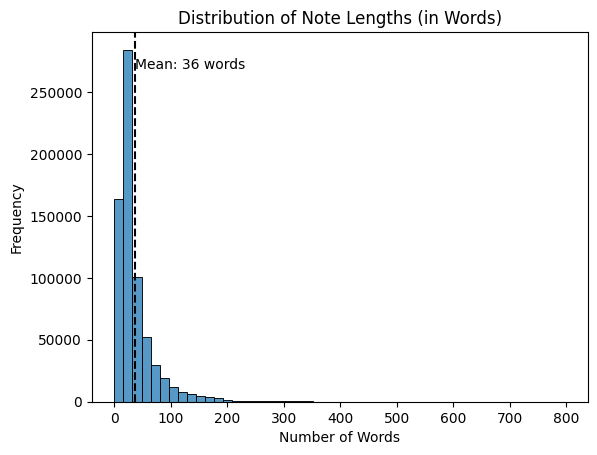

In [53]:
# Length of notes in words (histogram)
df['note_length_words'] = df['note_content'].fillna('').str.split().apply(len)

# Histogram of note lengths
ax = sns.histplot(df['note_length_words'], bins=50)

mean_val = df['note_length_words'].mean()
ax.axvline(mean_val, color='black', linestyle='--')
ax.text(mean_val, ax.get_ylim()[1] * 0.9, f'Mean: {mean_val:.0f} words', color='black')

ax.set(title='Distribution of Note Lengths (in Words)', xlabel='Number of Words', ylabel='Frequency')
plt.show()


In [54]:
def analyze_category_distribution(raw_df, taxonomy_df, log_scale=True):
    """Display graphs and metrics (IRLbl, MeanIR, MaxIR, CVIR) about the category distribution."""
    category_counts = raw_df[taxonomy_df['cat_label']].sum(axis=0).sort_values(ascending=False)
    df = taxonomy_df.join(category_counts.rename('frequency'), on='cat_label').sort_values('frequency', ascending=False)

    # IRLbl per label
    max_freq = df['frequency'].max()
    irlbl = max_freq / df['frequency']
    irlbl_df = pd.DataFrame({'label': df['category_description'].values, 'IRLbl': irlbl.values})
    display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))

    # Summary stats
    summary = pd.DataFrame({
        'Metric': ['MeanIR', 'MaxIR', 'CVIR'],
        'Value': [irlbl.mean(), irlbl.max(), irlbl.std() / irlbl.mean()]
    }).style.format({'Value': '{:.2f}'})
    display(summary)

    # Bar chart
    plt.figure(figsize=(13, 13), dpi=80)
    ax = sns.barplot(data=df, y='cat_label', x='frequency', dodge=False)
    # if log_scale:
    #    plt.xscale('log')
    ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)

    # plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.title(f"Count of Notes by Category (n={len(raw_df)}) {'(log scale)' if log_scale else ''}")
    plt.tight_layout()
    plt.show()

,label,IRLbl
0,"Disrepair, damp & mould",1.000000
1,Anti-Social Behaviour,1.744875
2,Infestation,10.463698
3,Mental Health,11.854569
4,Temporary,13.487217
5,Verbal Abuse or Threat of,15.711717
6,Domestic abuse,17.991634
7,Substance misuse,19.641026
8,Social care involvement,30.473025
9,Fire-related risks,32.322543


,Metric,Value
0,MeanIR,1626.05
1,MaxIR,55918.00
2,CVIR,5.30


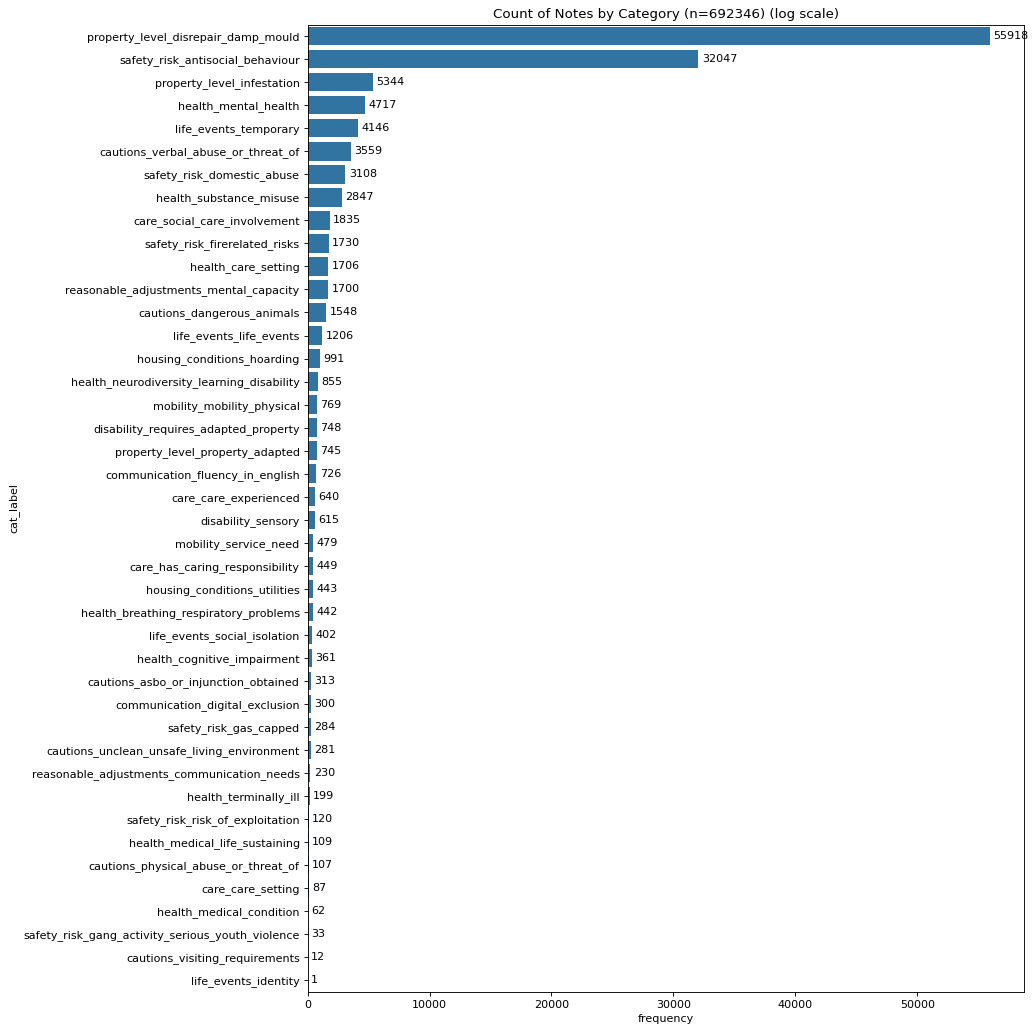

In [55]:
analyze_category_distribution(df, taxonomy)

In [56]:
def show_co_occurence_heatmap(raw_df, taxonomy_df):
    # Co-occurence heatmap
    cat_to_label = taxonomy_df.set_index('cat_label')['category_description'].to_dict()
    df_cats = raw_df[taxonomy_df['cat_label']].astype(int)  # Convert Booleans to 1s and 0s
    df_cats = df_cats.rename(columns=cat_to_label) # Pretty prints the categories
    co_matrix = df_cats.T.dot(df_cats) # Calculate co-occurrence by multiplying by transpose

    # Normalize against class frequencies (so majority classes don't blow out scale)
    class_frequencies = np.diag(co_matrix) # Extract raw frequencies (diagonal)
    normalized_matrix = co_matrix.div(class_frequencies, axis=0) 

    # Force diagonals to be 0s so they don't blow out scale
    normalized_matrix_arr = normalized_matrix.to_numpy(copy=True)
    np.fill_diagonal(normalized_matrix_arr, 0) 
    normalized_matrix = pd.DataFrame(normalized_matrix_arr, index=co_matrix.index, columns=co_matrix.columns)

    # Heatmap
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        normalized_matrix, 
        cmap="Blues", 
        annot=False, 
        linewidths=0.5, 
        linecolor='lightgrey',
        vmin=0, vmax=1, # percentage, will be 0-1
        cbar_kws={'label': 'Proportion of Co-occurrence P(Column | Row)'}
    )

    plt.title("Label Co-occurrence", fontsize=18, pad=20)
    plt.xlabel("ANs Categories", fontsize=14)
    plt.ylabel("ANs Categories", fontsize=14)

    plt.tight_layout()
    plt.show()

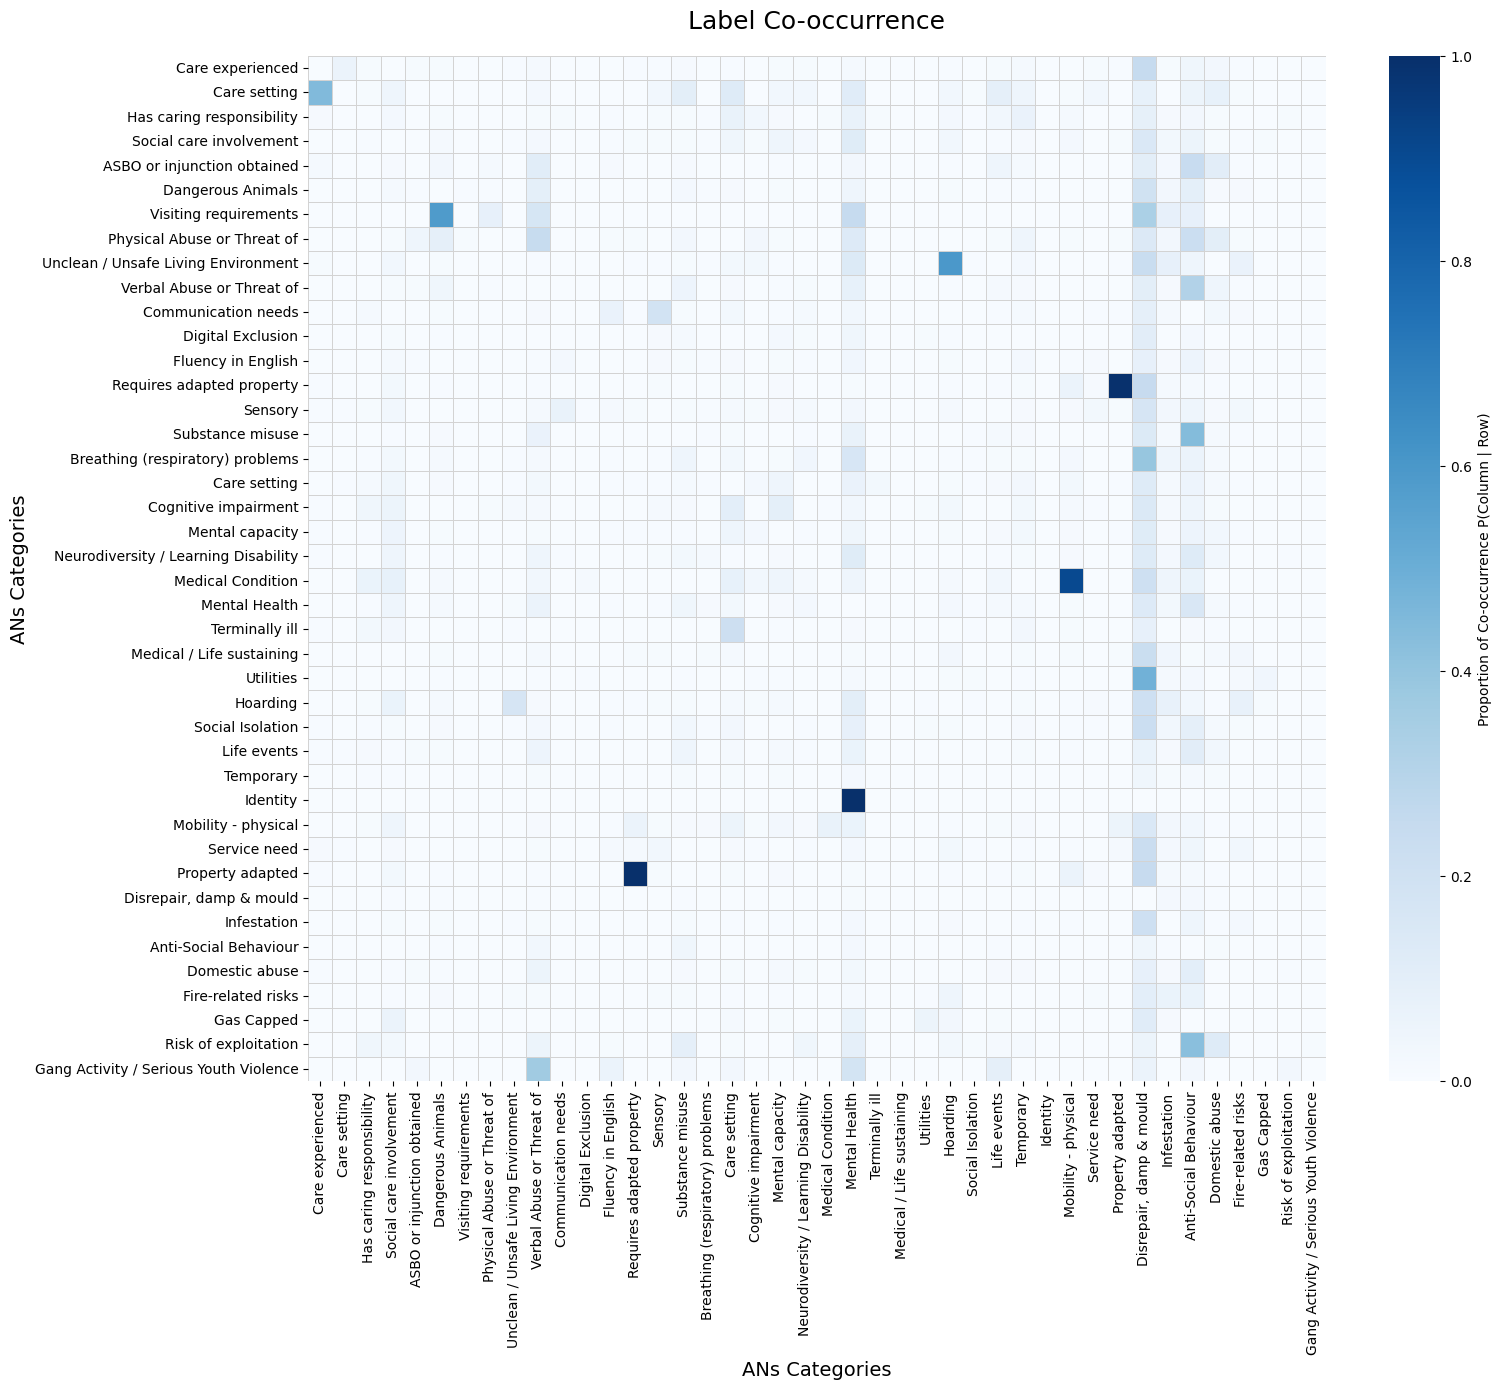

In [57]:
show_co_occurence_heatmap(df, taxonomy)

### Drop rare categories
Based on the EDA, drop categories to address class imbalance and ensure sufficient representation for sampling. Dropped categories will only rely on regex instead.

In [58]:
df_v2 = df.copy()
taxonomy_v2 = taxonomy.copy()

dropped_categories = [
    'life_events_identity', # Only one hit. Should drop.
    'cautions_visiting_requirements', # 12 hits
    'safety_risk_gang_activity_serious_youth_violence', # 33 hits
]

df_v2.drop(columns=dropped_categories, inplace=True)
mask = taxonomy_v2['cat_label'].isin(dropped_categories)
taxonomy_v2 = taxonomy_v2[~mask].reset_index(drop=True)
taxonomy_v2.to_csv("data/output/taxonomy_v2_autogen.csv", index=False)

taxonomy_v2.head()

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"[Care leaver, Care experienced (under 25)]",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"[Fostered, Social care]",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"[Formal, Informal]",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"[Adult Social Care, Children's Social Care]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"[ASBO, Injunction]",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


In [59]:
del df # memory saving

### Compare class imbalance
Compare the class imbalance before and after combining/dropping categories to assess the impact on the dataset.

,label,IRLbl
0,"Disrepair, damp & mould",1.000000
1,Anti-Social Behaviour,1.744875
2,Infestation,10.463698
3,Mental Health,11.854569
4,Temporary,13.487217
5,Verbal Abuse or Threat of,15.711717
6,Domestic abuse,17.991634
7,Substance misuse,19.641026
8,Social care involvement,30.473025
9,Fire-related risks,32.322543


,Metric,Value
0,MeanIR,154.41
1,MaxIR,901.90
2,CVIR,1.28


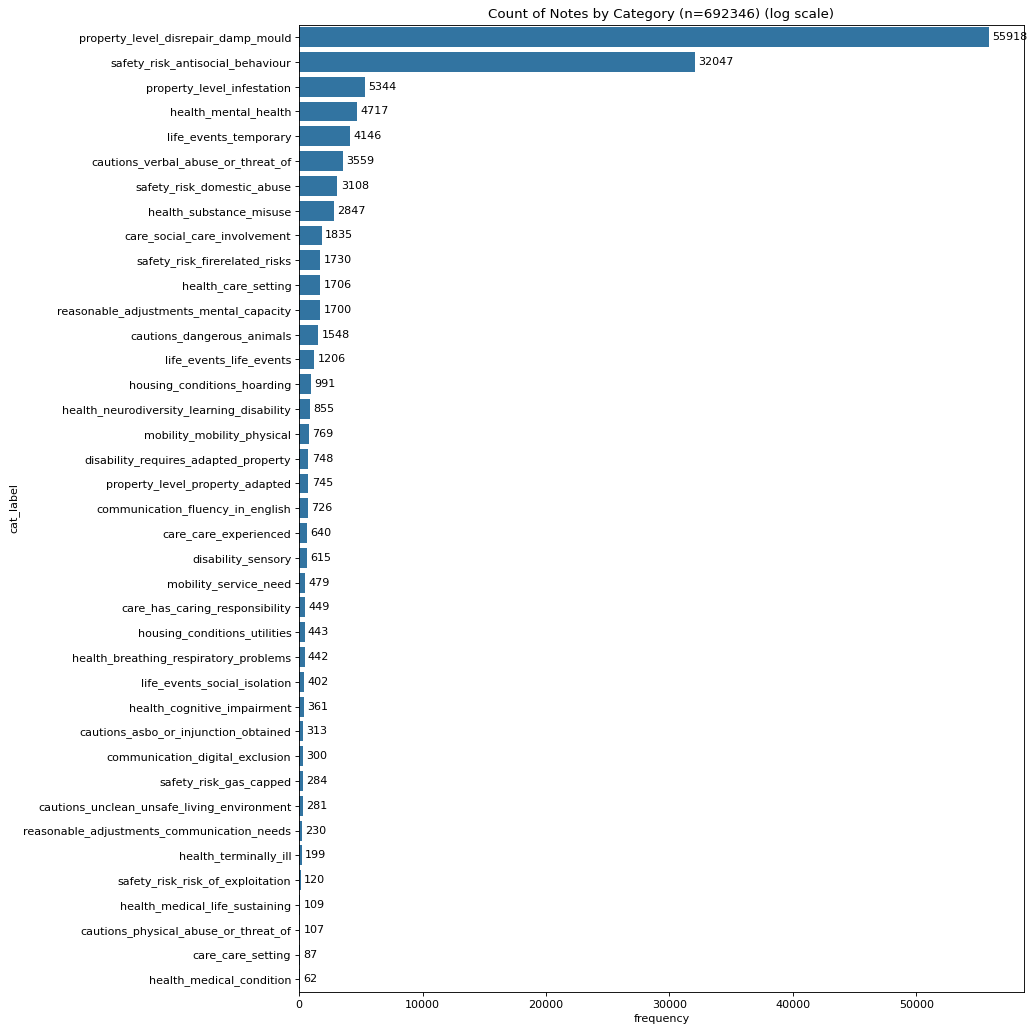

In [60]:
analyze_category_distribution(df_v2, taxonomy_v2)

## Construct Gold Standard Set
TODO explanation

### Stratified Sample (n=2000)
Perform stratified sampling based on the weak labels to create a balanced gold standard dataset of 2000 records for manual annotation.

In [61]:
# Get unflagged records - zero category matches.
df_v2['unflagged'] = ~df_v2[taxonomy_v2['cat_label']].any(axis=1)
df_v2['unflagged'].value_counts()

unflagged
True     576888
False    115458
Name: count, dtype: int64

In [62]:
sampled_data = []
sampled_ids = set()

# Sample categories by least prevalent (up to TARGET_PER_CAT)
category_counts = df_v2[taxonomy_v2['cat_label']].sum().sort_values(ascending=True)
for cat in category_counts.index:
    pool = df_v2[df_v2[cat] & ~df_v2['note_id'].isin(sampled_ids)] # In the category and not already sampled
    n = min(len(pool), TARGET_PER_CAT)
    if n > 0:
        sample = pool.sample(n=n, random_state=RANDOM_STATE)
        sampled_data.append(sample)
        sampled_ids.update(sample['note_id'].tolist())

# Sample unflagged (non-category matches) records
pool = df_v2[df_v2['unflagged'] & ~df_v2['note_id'].isin(sampled_ids)]
n = min(len(pool), TARGET_TOTAL - len(sampled_ids))
if n > 0:
    sample = pool.sample(n=n, random_state=RANDOM_STATE)
    sampled_data.append(sample)
    sampled_ids.update(sample['note_id'].tolist())

# Combine and shuffle
final_sample = pd.concat(sampled_data).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [63]:
final_sample.drop(columns=['note_id', 'note_content', 'note_category', 'note_length_words']).sum().sort_values()

health_medical_life_sustaining                 45
cautions_physical_abuse_or_threat_of           45
care_care_setting                              46
health_terminally_ill                          46
safety_risk_gas_capped                         47
health_medical_condition                       47
safety_risk_risk_of_exploitation               47
communication_digital_exclusion                47
cautions_asbo_or_injunction_obtained           48
mobility_service_need                          49
health_breathing_respiratory_problems          49
housing_conditions_utilities                   51
reasonable_adjustments_communication_needs     52
communication_fluency_in_english               52
life_events_social_isolation                   53
health_cognitive_impairment                    54
care_has_caring_responsibility                 55
cautions_unclean_unsafe_living_environment     57
health_neurodiversity_learning_disability      58
disability_sensory                             61


In [64]:
del df_v2 # Memory saving

### Compare class imbalance
Compare the class imbalance in the gold standard set to the original dataset to evaluate the effectiveness of the sampling strategy.

,label,IRLbl
0,"Disrepair, damp & mould",1.000000
1,Anti-Social Behaviour,1.741379
2,Mental Health,2.089655
3,Mobility - physical,2.913462
4,Requires adapted property,3.030000
5,Verbal Abuse or Threat of,3.030000
6,Property adapted,3.091837
7,Infestation,3.156250
8,Care setting,3.223404
9,Hoarding,3.223404


,Metric,Value
0,MeanIR,4.77
1,MaxIR,6.73
2,CVIR,0.33


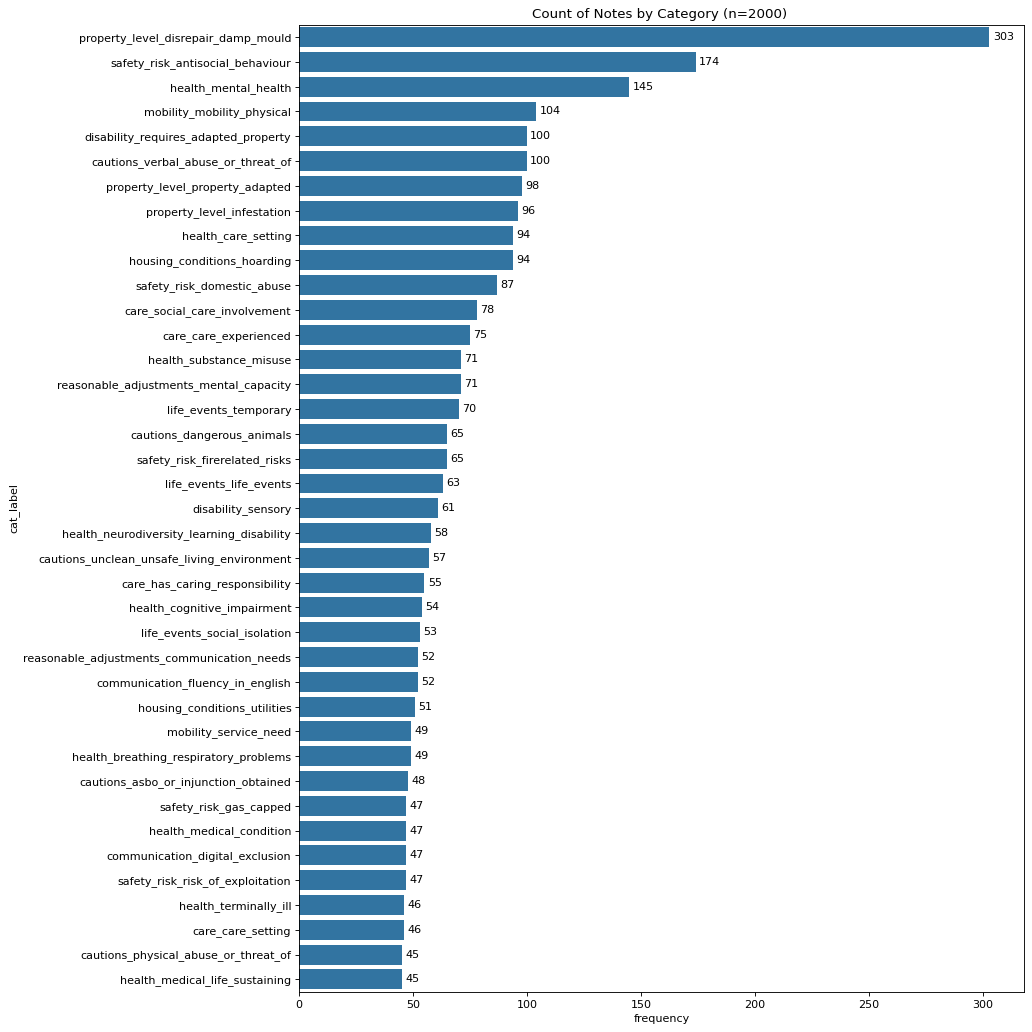

In [65]:
analyze_category_distribution(final_sample, taxonomy_v2, log_scale=False)

### PII (Personally-Identifiable Information) Redaction
Apply PII redaction techniques to the gold standard dataset to ensure privacy and compliance with GDPR before manually annotating.

In [66]:
# Set up engines
fake = Faker('en')
Faker.seed(RANDOM_STATE)

analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

In [67]:
# Regex matcher for UK postcodes
uk_postcode_pattern = Pattern(
    name="uk_postcode_regex", 
    regex=r"\b([Gg][Ii][Rr] 0[Aa]{2})|((([A-Za-z][0-9]{1,2})|(([A-Za-z][A-Ha-hJ-Yj-y][0-9]{1,2})|(([A-Za-z][0-9][A-Za-z])|([A-Za-z][A-Ha-hJ-Yj-y][0-9][A-Za-z]?))))\s?[0-9][A-Za-z]{2})\b", 
    score=0.85
)
uk_postcode_recognizer = PatternRecognizer(
    supported_entity="UK_POSTCODE", 
    patterns=[uk_postcode_pattern]
)
analyzer.registry.add_recognizer(uk_postcode_recognizer)

In [68]:
# Define target entities to redact
target_entities = [
    "PERSON", 
    "EMAIL_ADDRESS", 
    "PHONE_NUMBER", 
    "DATE_TIME",
    "LOCATION",
    "UK_POSTCODE", 
    "CREDIT_CARD", 
    "IBAN_CODE", 
    "IP_ADDRESS",
    "URL"
]

# Replace names with fake names
consistent_name_map = {}
def get_consistent_fake_name(text):
    if text not in consistent_name_map:
        consistent_name_map[text] = fake.name()
    return consistent_name_map[text]

# Define operator for each entity type
operators = {
    "PERSON": OperatorConfig("custom", {"lambda": get_consistent_fake_name}),
    "DEFAULT": OperatorConfig("replace") # Automatically replaces with e.g., <PHONE_NUMBER>
}

In [69]:
# Track what was found and replaced per note
def anonymize_and_extract_spans(text):
    if not isinstance(text, str):
        return pd.Series({'note_content': text, 'fake_name_spans': []})
        
    # Analyze
    results = analyzer.analyze(text=text, entities=target_entities, language='en')
    
    # Anonymize
    anonymized = anonymizer.anonymize(
        text=text,
        analyzer_results=results,
        operators=operators
    )
    
    fake_spans = []
    for item in anonymized.items:
        if item.entity_type == 'PERSON':
            # Highlight replaced names as fake
            fake_spans.append({
                'start': item.start,
                'end': item.end,
                'text': item.text, 
                'labels': ['Pseudonym'] 
            })
    
    return pd.Series({
        'note_content': anonymized.text,
        'fake_name_spans': fake_spans
    })



tqdm.pandas() # Enable pandas progress_apply (for progress bar)
scrubbed_df = final_sample.copy()
scrubbed_df[['note_content', 'fake_name_spans']] = scrubbed_df['note_content'].progress_apply(anonymize_and_extract_spans)

100%|██████████| 2000/2000 [00:37<00:00, 53.33it/s]


In [76]:
with open(f"data/output/consistent_name_map.json", "w") as f:
    json.dump(consistent_name_map, f, indent=2)

### Pre-Annotation
Pre-annotate the category spans, pseudonyms, and entity reference (pronouns and role such as tenant). This will speed up manual annoation.

In [71]:
# Construct regexes for ANs & entities 
person_role_regex = r"(?i)\b(tenant|tenants|leaseholder|leaseholders|resident|residents|child|children|son|daughter|partner|wife|husband|mother|father|caller|applicant|neighbour|neighbor|neighbours|neighbor)\b" # common housing roles
compiled_role_regex = re.compile(person_role_regex)
compiled_category_regex = {row.cat_label: re.compile(row.regex) for row in taxonomy_v2.itertuples()}

In [72]:
# Loop through cleaned sample

label_studio_tasks = []
for index, row in tqdm(scrubbed_df.iterrows()):
    note_content = str(row['note_content'])
    note_id = str(row['note_id'])
    
    identified_labels = []
    
    # --- AN Tags ---
    for cat_key, compiled_regex in compiled_category_regex.items():
        for match in compiled_regex.finditer(note_content):
            identified_labels.append({
                "from_name": "need_labels",  # Matches Label Studio XML
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": match.start(), # Extract the specific span - didn't do with the whole dataset as it is expensive.
                    "end": match.end(),
                    "text": match.group(),
                    "labels": [cat_key]
                }
            })

    # --- Role Labels ---
    for match in compiled_role_regex.finditer(note_content):
        identified_labels.append({
            "from_name": "entity_labels",  # Matches Label Studio XML
            "to_name": "text",
            "type": "labels",
            "value": {
                "start": match.start(),
                "end": match.end(),
                "text": match.group(),
                "labels": ["Person Role"]
            }
        })

    # --- Fake name Spans (Presidio) ---
    for span in row['fake_name_spans']:
        identified_labels.append({
            "from_name": "entity_labels", # Matches Label Studio XML
            "to_name": "text",
            "type": "labels",
            "value": {
                "start": span['start'],
                "end": span['end'],
                "text": span['text'],
                "labels": span['labels']
            }
        })
    
    # --- Construct label studio task ---
    task = {
        "data": {
            "note_content": note_content,
            "id": note_id
        },
        "predictions": [{
            "model_version": "pre_annotated",
            "score": 1.0,
            "result": identified_labels
        }]
    }
    
    label_studio_tasks.append(task)

len(label_studio_tasks)

2000it [00:01, 1900.94it/s]


2000

In [73]:
label_studio_tasks[:2]

[{'data': {'note_content': '[Category: Rents] Telephone line just ringing',
   'id': '4d1f84da-85f0-9837-33ac-bdc3ae96fcba'},
  'predictions': [{'model_version': 'pre_annotated',
    'score': 1.0,
    'result': []}]},
 {'data': {'note_content': '[Category: tenureManagement] Welfare check and tenancy audit completed I visited the tenant in his property following his request for me to come over and assess the toilet in his property. I used the opportunity to complete a tenancy audit and I observed that he is a hoarder with so many items in nearly all the rooms. The toilet seat has broken and the toilet is as dark as charcoal.',
   'id': '685524bb-94d4-4f08-8669-0e78df744c0c'},
  'predictions': [{'model_version': 'pre_annotated',
    'score': 1.0,
    'result': [{'from_name': 'need_labels',
      'to_name': 'text',
      'type': 'labels',
      'value': {'start': 268,
       'end': 275,
       'text': 'hoarder',
       'labels': ['cautions_unclean_unsafe_living_environment']}},
     {'fro

### Export sample set

In [77]:
with open(f"data/output/gold_standard_sample.json", "w") as f:
    json.dump(label_studio_tasks, f, indent=2)

In [78]:
# CSV
pd.DataFrame(label_studio_tasks).to_csv(f"data/output/gold_standard_sample.csv", index=False)